<a href="https://colab.research.google.com/github/wilsonvimala/TNSDC-Generative-AI/blob/main/ABA_FINAL_PROJECT_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
!pip install optuna
import optuna
import os
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, precision_recall_curve
warnings.filterwarnings('ignore')

In [16]:
import pandas as pd

# Read all datasets
application_train = pd.read_csv("application_train.csv")
application_test = pd.read_csv("application_test.csv")
bureau = pd.read_csv("bureau.csv")
bureau_balance = pd.read_csv("bureau_balance.csv")
credit_card_balance = pd.read_csv("credit_card_balance.csv")
installments_payments = pd.read_csv("installments_payments.csv")
previous_application = pd.read_csv("previous_application.csv")
pos_cash_balance = pd.read_csv("POS_CASH_balance.csv")

# Check first few rows
print(application_train.head())

   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...               0.0             

In [17]:
def memory_optimizer(df, threshold=0.5):
    """
    Optimize memory usage of a pandas DataFrame by downcasting numeric columns
    and converting suitable object columns to categorical type.

    Parameters:
    - df: pandas DataFrame to optimize
    - threshold: float, optional (default=0.5)
        Maximum ratio of unique values to total rows for converting object columns
        to category. If nunique() / len(df) < threshold, the column is converted.

    Returns:
    - df: Optimized pandas DataFrame (modified in place)
    """
    for col in df:
        # Downcast float64 columns to the smallest float type
        if df[col].dtype == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        # Downcast int64 columns to the smallest integer type
        elif df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
        # Convert object columns to category if unique values are below threshold
        elif df[col].dtype == 'object':
            if df[col].nunique() / len(df) < threshold:
                df[col] = df[col].astype('category')
    return df


In [18]:
application_train = memory_optimizer(application_train)
bureau = memory_optimizer(bureau)
previous_application = memory_optimizer(previous_application)
installments_payments = memory_optimizer(installments_payments)
credit_card_balance = memory_optimizer(credit_card_balance)
bureau_balance = memory_optimizer(bureau_balance)

In [19]:
application_train.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11631 entries, 0 to 11630
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: category(16), float32(102), float64(1), int32(1), int8(2)
memory usage: 4.9 MB


In [20]:
bureau.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1036966 entries, 0 to 1036965
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   SK_ID_CURR              1036966 non-null  int32   
 1   SK_ID_BUREAU            1036966 non-null  int32   
 2   CREDIT_ACTIVE           1036966 non-null  category
 3   CREDIT_CURRENCY         1036966 non-null  category
 4   DAYS_CREDIT             1036966 non-null  int16   
 5   CREDIT_DAY_OVERDUE      1036966 non-null  int16   
 6   DAYS_CREDIT_ENDDATE     972676 non-null   float32 
 7   DAYS_ENDDATE_FACT       652054 non-null   float32 
 8   AMT_CREDIT_MAX_OVERDUE  354051 non-null   float64 
 9   CNT_CREDIT_PROLONG      1036966 non-null  int8    
 10  AMT_CREDIT_SUM          1036959 non-null  float64 
 11  AMT_CREDIT_SUM_DEBT     881329 non-null   float64 
 12  AMT_CREDIT_SUM_LIMIT    676562 non-null   float64 
 13  AMT_CREDIT_SUM_OVERDUE  1036965 non-null  

In [21]:
previous_application.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1135707 entries, 0 to 1135706
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype   
---  ------                       --------------    -----   
 0   SK_ID_PREV                   1135707 non-null  int32   
 1   SK_ID_CURR                   1135707 non-null  int32   
 2   NAME_CONTRACT_TYPE           1135707 non-null  category
 3   AMT_ANNUITY                  883723 non-null   float64 
 4   AMT_APPLICATION              1135707 non-null  float64 
 5   AMT_CREDIT                   1135706 non-null  float64 
 6   AMT_DOWN_PAYMENT             531035 non-null   float64 
 7   AMT_GOODS_PRICE              875265 non-null   float64 
 8   WEEKDAY_APPR_PROCESS_START   1135706 non-null  category
 9   HOUR_APPR_PROCESS_START      1135706 non-null  float32 
 10  FLAG_LAST_APPL_PER_CONTRACT  1135706 non-null  category
 11  NFLAG_LAST_APPL_IN_DAY       1135706 non-null  float32 
 12  RATE_DOWN_PAYMENT           

In [22]:
installments_payments.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3866907 entries, 0 to 3866906
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int32  
 1   SK_ID_CURR              int32  
 2   NUM_INSTALMENT_VERSION  float32
 3   NUM_INSTALMENT_NUMBER   float32
 4   DAYS_INSTALMENT         float32
 5   DAYS_ENTRY_PAYMENT      float32
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float32(4), float64(2), int32(2)
memory usage: 147.5 MB


In [23]:
credit_card_balance.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 563531 entries, 0 to 563530
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype   
---  ------                      --------------   -----   
 0   SK_ID_PREV                  563531 non-null  int32   
 1   SK_ID_CURR                  563531 non-null  int32   
 2   MONTHS_BALANCE              563531 non-null  int8    
 3   AMT_BALANCE                 563531 non-null  float64 
 4   AMT_CREDIT_LIMIT_ACTUAL     563531 non-null  int32   
 5   AMT_DRAWINGS_ATM_CURRENT    446303 non-null  float64 
 6   AMT_DRAWINGS_CURRENT        563531 non-null  float64 
 7   AMT_DRAWINGS_OTHER_CURRENT  446303 non-null  float64 
 8   AMT_DRAWINGS_POS_CURRENT    446303 non-null  float64 
 9   AMT_INST_MIN_REGULARITY     522961 non-null  float64 
 10  AMT_PAYMENT_CURRENT         445152 non-null  float64 
 11  AMT_PAYMENT_TOTAL_CURRENT   563531 non-null  float64 
 12  AMT_RECEIVABLE_PRINCIPAL    563531 non-null  float64 
 13 

In [24]:
bureau_balance.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3584520 entries, 0 to 3584519
Data columns (total 3 columns):
 #   Column          Dtype   
---  ------          -----   
 0   SK_ID_BUREAU    int32   
 1   MONTHS_BALANCE  float32 
 2   STATUS          category
dtypes: category(1), float32(1), int32(1)
memory usage: 30.8 MB


In [25]:
print('app train shape:', application_train.shape)
print('bureau shape:', bureau.shape)
print('prev app shape:', previous_application.shape)
print('installments payments shape:', installments_payments.shape)
print('credit card balance shape:', credit_card_balance.shape)
print('bureau balance shape:', bureau_balance.shape)

app train shape: (11631, 122)
bureau shape: (1036966, 17)
prev app shape: (1135707, 37)
installments payments shape: (3866907, 8)
credit card balance shape: (563531, 23)
bureau balance shape: (3584520, 3)


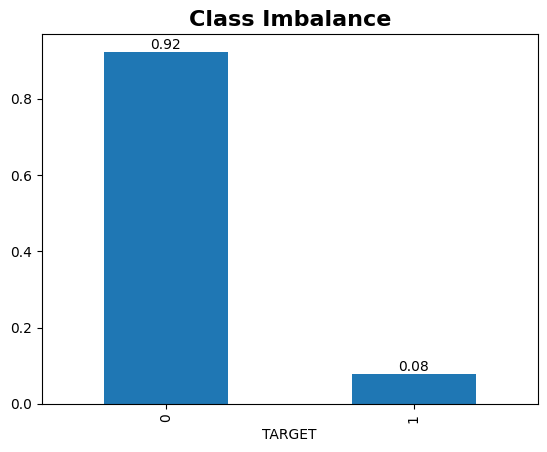

In [26]:
# Create bar plot
ax = application_train['TARGET'].value_counts(normalize=True).plot(kind='bar')

# Annotate each bar with its value
for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom')

# Show the plot
plt.title('Class Imbalance' ,fontweight='bold', fontsize=16)
plt.show()

In [27]:
application_train[['AMT_CREDIT','AMT_INCOME_TOTAL',
           'AMT_ANNUITY','DEF_30_CNT_SOCIAL_CIRCLE',
           'DEF_60_CNT_SOCIAL_CIRCLE']].isna().sum()

,0
AMT_CREDIT,0
AMT_INCOME_TOTAL,0
AMT_ANNUITY,0
DEF_30_CNT_SOCIAL_CIRCLE,51
DEF_60_CNT_SOCIAL_CIRCLE,51


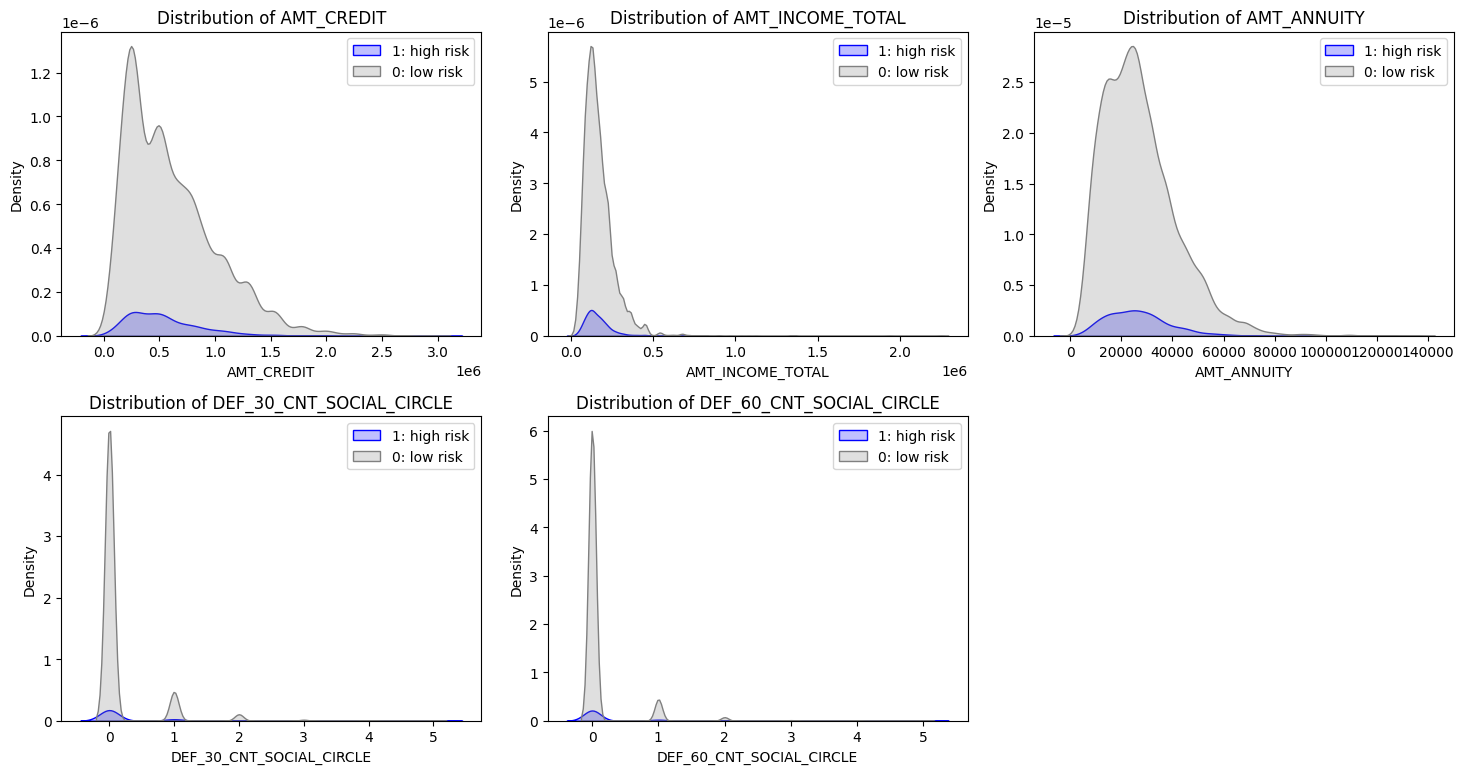

In [28]:
cols = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
        'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = application_train.copy()
    data[col] = data[col].fillna(0)
    ax = axes[i]
    sns.kdeplot(data=data, x=col, fill=True, hue='TARGET',
                palette={0:'grey', 1:'blue'}, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f'Distribution of {col}')
    ax.legend(['1: high risk', '0: low risk'])

# Remove any extra subplots if the grid is larger than needed
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

del cols, n_cols, n_rows, fig, axes, data, ax

In [29]:
print(f"AMT_INCOME_TOTAL descriptive stats:\n{application_train['AMT_INCOME_TOTAL'].describe().round(1)}")
print()
print()
print(f"Count of default from the highest income:\n{application_train.loc[application_train['AMT_INCOME_TOTAL']>application_train['AMT_INCOME_TOTAL'].quantile(.99), ['TARGET']].value_counts()}")

AMT_INCOME_TOTAL descriptive stats:
count      11631.0
mean      167872.0
std        96491.0
min        25650.0
25%       112500.0
50%       144000.0
75%       202500.0
max      2250000.0
Name: AMT_INCOME_TOTAL, dtype: float64


Count of default from the highest income:
TARGET
0         106
1           5
Name: count, dtype: int64


**162 of the people with the highest income has difficulty paying?**

In [30]:
print(f"DEF_30_CNT_SOCIAL_CIRCLE descriptive stats:\n{application_train['DEF_30_CNT_SOCIAL_CIRCLE'].describe().round(1)}")
print()
print()
print(f"DEF_30_CNT_SOCIAL_CIRCLE 99th quantile:\n{application_train['DEF_30_CNT_SOCIAL_CIRCLE'].quantile(.99)}")

DEF_30_CNT_SOCIAL_CIRCLE descriptive stats:
count    11580.0
mean         0.1
std          0.5
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          5.0
Name: DEF_30_CNT_SOCIAL_CIRCLE, dtype: float64


DEF_30_CNT_SOCIAL_CIRCLE 99th quantile:
2.0


**99th percentile is far away max value. not good.**

In [31]:
print(f"DEF_60_CNT_SOCIAL_CIRCLE descriptive stats:\n{application_train['DEF_60_CNT_SOCIAL_CIRCLE'].describe().round(1)}")
print()
print()
print(f"DEF_60_CNT_SOCIAL_CIRCLE 99th quantile:\n{application_train['DEF_60_CNT_SOCIAL_CIRCLE'].quantile(.99)}")

DEF_60_CNT_SOCIAL_CIRCLE descriptive stats:
count    11580.0
mean         0.1
std          0.4
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          5.0
Name: DEF_60_CNT_SOCIAL_CIRCLE, dtype: float64


DEF_60_CNT_SOCIAL_CIRCLE 99th quantile:
2.0


**99th percentile is far away from max value. not good.**

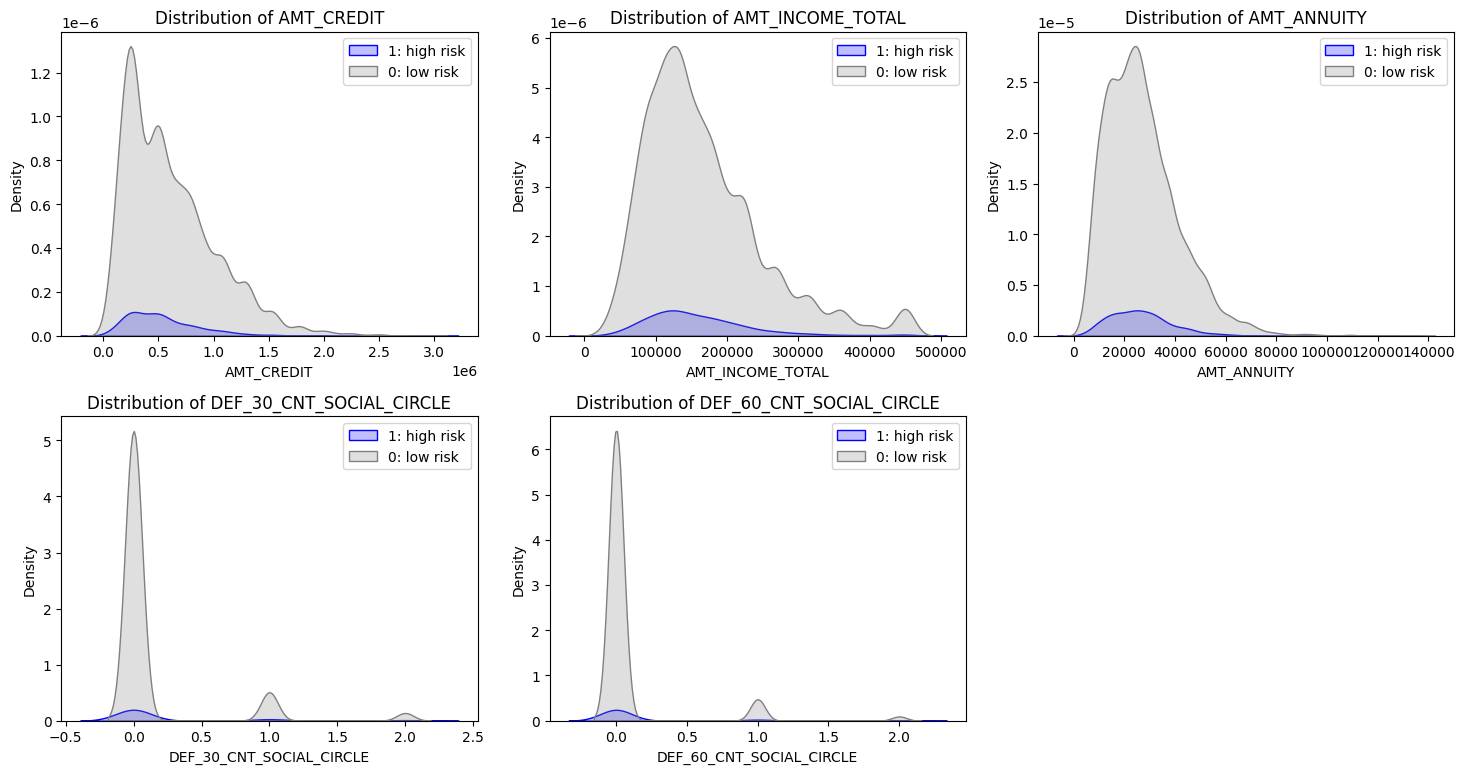

In [32]:
cols = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
        'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = application_train.copy()
    data[col] = data[col].fillna(0)
    if col in ['AMT_INCOME_TOTAL', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']:
        data[col] = np.where(data[col] > data[col].quantile(.99), data[col].quantile(.99), data[col])
    ax = axes[i]
    sns.kdeplot(data=data, x=col, fill=True, hue='TARGET',
                palette={0:'grey', 1:'blue'}, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f'Distribution of {col}')
    ax.legend(['1: high risk', '0: low risk'])

# Remove any extra subplots if the grid is larger than needed
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

del cols, n_cols, n_rows, fig, axes, data, ax

**Capped values at 99th percentile**

In [33]:
for col in ['AMT_INCOME_TOTAL', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']:
    application_train[col] = np.where(application_train[col] > application_train[col].quantile(.99),
                              application_train[col].quantile(.99),
                              application_train[col])

application_train[['AMT_ANNUITY', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'AMT_GOODS_PRICE']].fillna(0, inplace=True)

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_INCOME_TOTAL']:
    application_train[col].fillna(application_train[col].median(), inplace=True)

application_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Features from bureau table¶
bureau.csv data concerns client's earlier credits from other financial institutions.
A single client might have taken other loans from other financial institutions.
For each row in the application_train data we can have multiple rows in this table (one to many relationship).

In [34]:
bureau[['CREDIT_DAY_OVERDUE','AMT_CREDIT_SUM_OVERDUE',
        'AMT_CREDIT_MAX_OVERDUE','AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM']].isna().sum()

,0
CREDIT_DAY_OVERDUE,0
AMT_CREDIT_SUM_OVERDUE,1
AMT_CREDIT_MAX_OVERDUE,682915
AMT_CREDIT_SUM_DEBT,155637
AMT_CREDIT_SUM,7


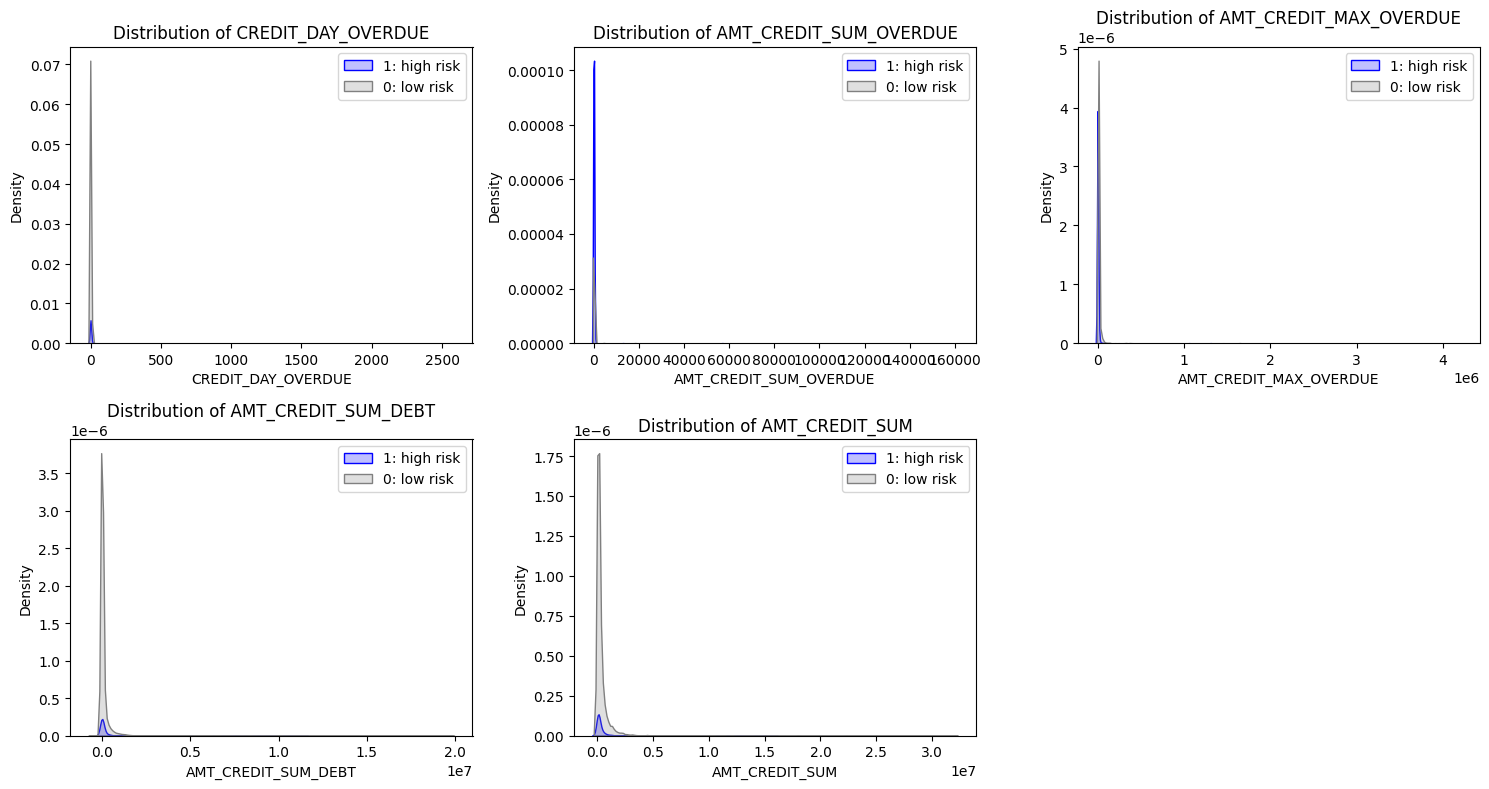

In [35]:
cols = ['CREDIT_DAY_OVERDUE','AMT_CREDIT_SUM_OVERDUE',
        'AMT_CREDIT_MAX_OVERDUE','AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM']

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = bureau.merge(application_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='left').copy()
    data[col] = data[col].fillna(data[col].median())
    ax = axes[i]
    sns.kdeplot(data, x=col, fill=True, hue='TARGET',
                palette={0:'grey', 1:'blue'}, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f'Distribution of {col}')
    ax.legend(['1: high risk', '0: low risk'])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

del cols, n_cols, n_rows, fig, axes, data, ax

All of theses distributions are heavily right skewed, meaning there are extreme outliers. not good.¶


In [36]:
for col in ['CREDIT_DAY_OVERDUE','AMT_CREDIT_SUM_OVERDUE',
        'AMT_CREDIT_MAX_OVERDUE','AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM']:
    print(bureau[col].describe().round(1))
    print(f"99th Percentile: {bureau[col].quantile(.99)}")
    print()

count    1036966.0
mean           0.8
std           36.8
min            0.0
25%            0.0
50%            0.0
75%            0.0
max         2781.0
Name: CREDIT_DAY_OVERDUE, dtype: float64
99th Percentile: 0.0

count    1036965.0
mean          36.3
std         5716.9
min            0.0
25%            0.0
50%            0.0
75%            0.0
max      3756681.0
Name: AMT_CREDIT_SUM_OVERDUE, dtype: float64
99th Percentile: 0.0

count       354051.0
mean          4193.8
std         261900.5
min              0.0
25%              0.0
50%              0.0
75%              0.0
max      115987185.0
Name: AMT_CREDIT_MAX_OVERDUE, dtype: float64
99th Percentile: 42799.5

count       881329.0
mean        138627.2
std         690751.0
min       -4705600.3
25%              0.0
50%              0.0
75%          42838.1
max      170100000.0
Name: AMT_CREDIT_SUM_DEBT, dtype: float64
99th Percentile: 2266381.259999997

count      1036959.0
mean        356511.4
std        1074325.5
min              0

In [37]:
bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'] < 0, 'AMT_CREDIT_SUM_DEBT']

,AMT_CREDIT_SUM_DEBT
21,-411.615
87,-2692.170
88,-149.040
89,-2.565
125,-701.280
...,...
1034321,-0.900
1034422,-91.215
1034423,-752.580
1034424,-6723.720


Negative values in AMT_CREDIT_SUM_DEBT?

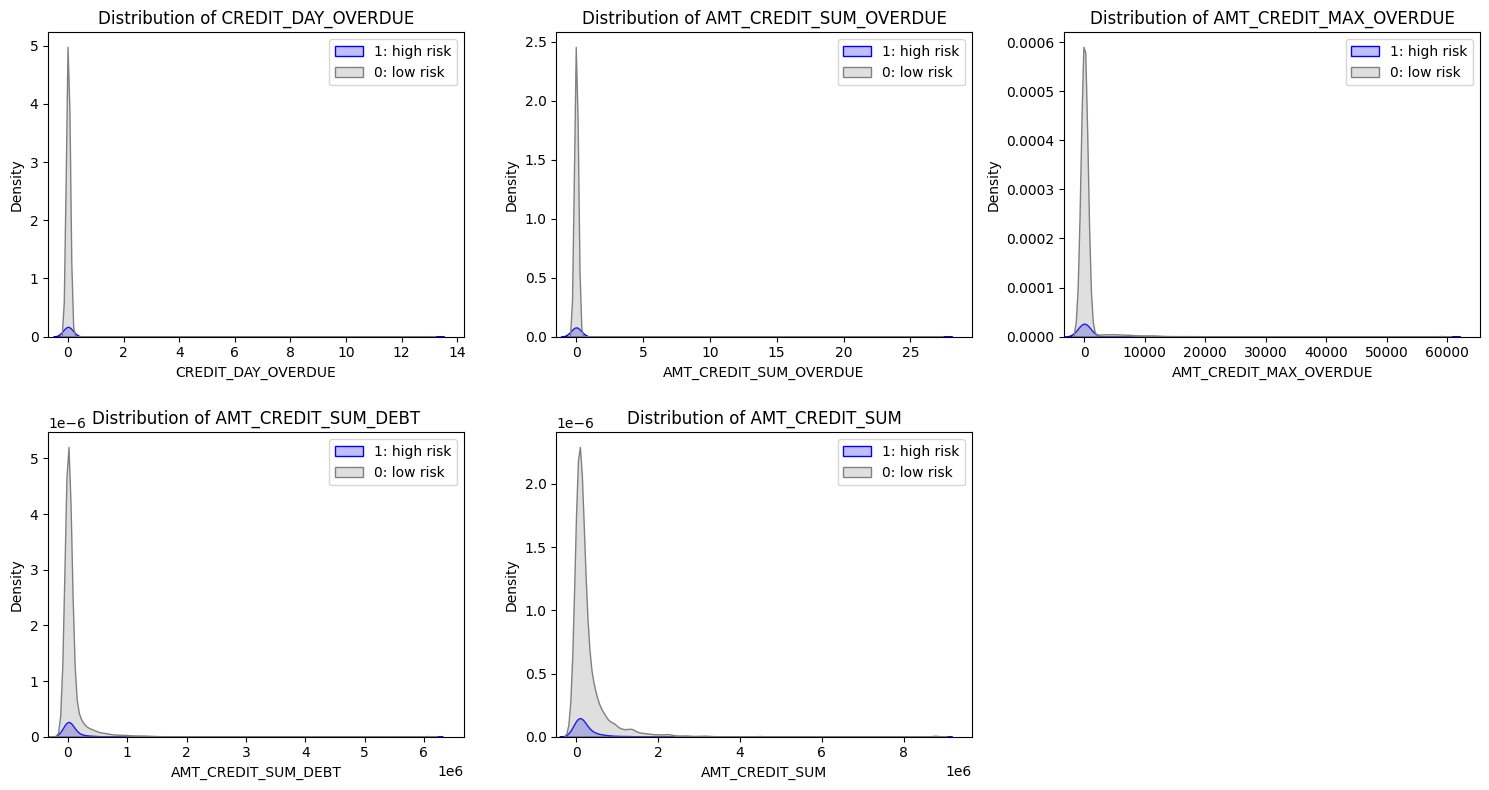

In [38]:
cols = ['CREDIT_DAY_OVERDUE','AMT_CREDIT_SUM_OVERDUE',
        'AMT_CREDIT_MAX_OVERDUE','AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM']

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = bureau.merge(application_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='left').copy()
    data[col] = data[col].fillna(data[col].median())
    if data[col].quantile(.998) > 0:
        data[col] = np.where(data[col] > data[col].quantile(.998), data[col].quantile(.998), data[col])
    elif data[col].min() < 0:
        data.loc[data[col] < 0, col] = 0
    ax = axes[i]
    sns.kdeplot(data=data, x=col, fill=True, hue='TARGET',
                palette={0:'grey', 1:'blue'}, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f'Distribution of {col}')
    ax.legend(['1: high risk', '0: low risk'])
    ax.set_xlim(-0.05 * ax.get_xlim()[1], None)

# Remove any extra subplots if the grid is larger than needed
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

del cols, n_cols, n_rows, fig, axes, data, ax

99.8th percentile for AMT_CREDIT_SUM_OVERDUE is only 26. Doesn't make sense. Let's not use that column in modelling¶
Maybe create binary overdue flag instead
Replace negative values in AMT_CREDITSUM DEBT with 0¶

In [39]:
bureau['overdue_flag'] = np.where(bureau['CREDIT_DAY_OVERDUE'] > 0, 1, 0)

bureau.loc[bureau['AMT_CREDIT_SUM_DEBT'] < 0, 'AMT_CREDIT_SUM_DEBT'] = 0

# Overdue-related columns: fill missing with 0, as missing implies no overdue/debt
bureau['AMT_CREDIT_MAX_OVERDUE'].fillna(0, inplace=True)
bureau['AMT_CREDIT_SUM_DEBT'].fillna(0, inplace=True)

# For AMT_CREDIT_SUM, fill missing with the median
bureau['AMT_CREDIT_SUM'].fillna(bureau['AMT_CREDIT_SUM'].median(), inplace=True)

for col in ['AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM', 'AMT_CREDIT_MAX_OVERDUE']:
    bureau[col] = np.where(bureau[col] > bureau[col].quantile(.99),
                           bureau[col].quantile(.99),
                           bureau[col])

bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,overdue_flag
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,0.000,0,91323.0,0.0,NaN,0.0,Consumer credit,-131.0,NaN,0
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,0.000,0,225000.0,171342.0,NaN,0.0,Credit card,-20.0,NaN,0
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,0.000,0,464323.5,0.0,NaN,0.0,Consumer credit,-16.0,NaN,0
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,0.000,0,90000.0,0.0,NaN,0.0,Credit card,-16.0,NaN,0
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,21318.201,0,2700000.0,0.0,NaN,0.0,Consumer credit,-21.0,NaN,0


Features from previous_application table¶
This table has details of previous applications made by clients to Home Credit.
Each current loan in the application data (identified by SK_ID_CURR) can have multiple previous loan applications.
Each previous application has one row and is identified by the feature SK_ID_PREV.

In [40]:
previous_application[['AMT_ANNUITY','AMT_APPLICATION',
       'AMT_CREDIT','AMT_GOODS_PRICE','RATE_DOWN_PAYMENT',
       'RATE_INTEREST_PRIMARY','AMT_DOWN_PAYMENT']].isna().sum()

,0
AMT_ANNUITY,251984
AMT_APPLICATION,0
AMT_CREDIT,1
AMT_GOODS_PRICE,260442
RATE_DOWN_PAYMENT,604673
RATE_INTEREST_PRIMARY,1131652
AMT_DOWN_PAYMENT,604672


**Filling these NaN values with 0 doesn't make sense since they're monetary values
Gonna fill them with median instead**


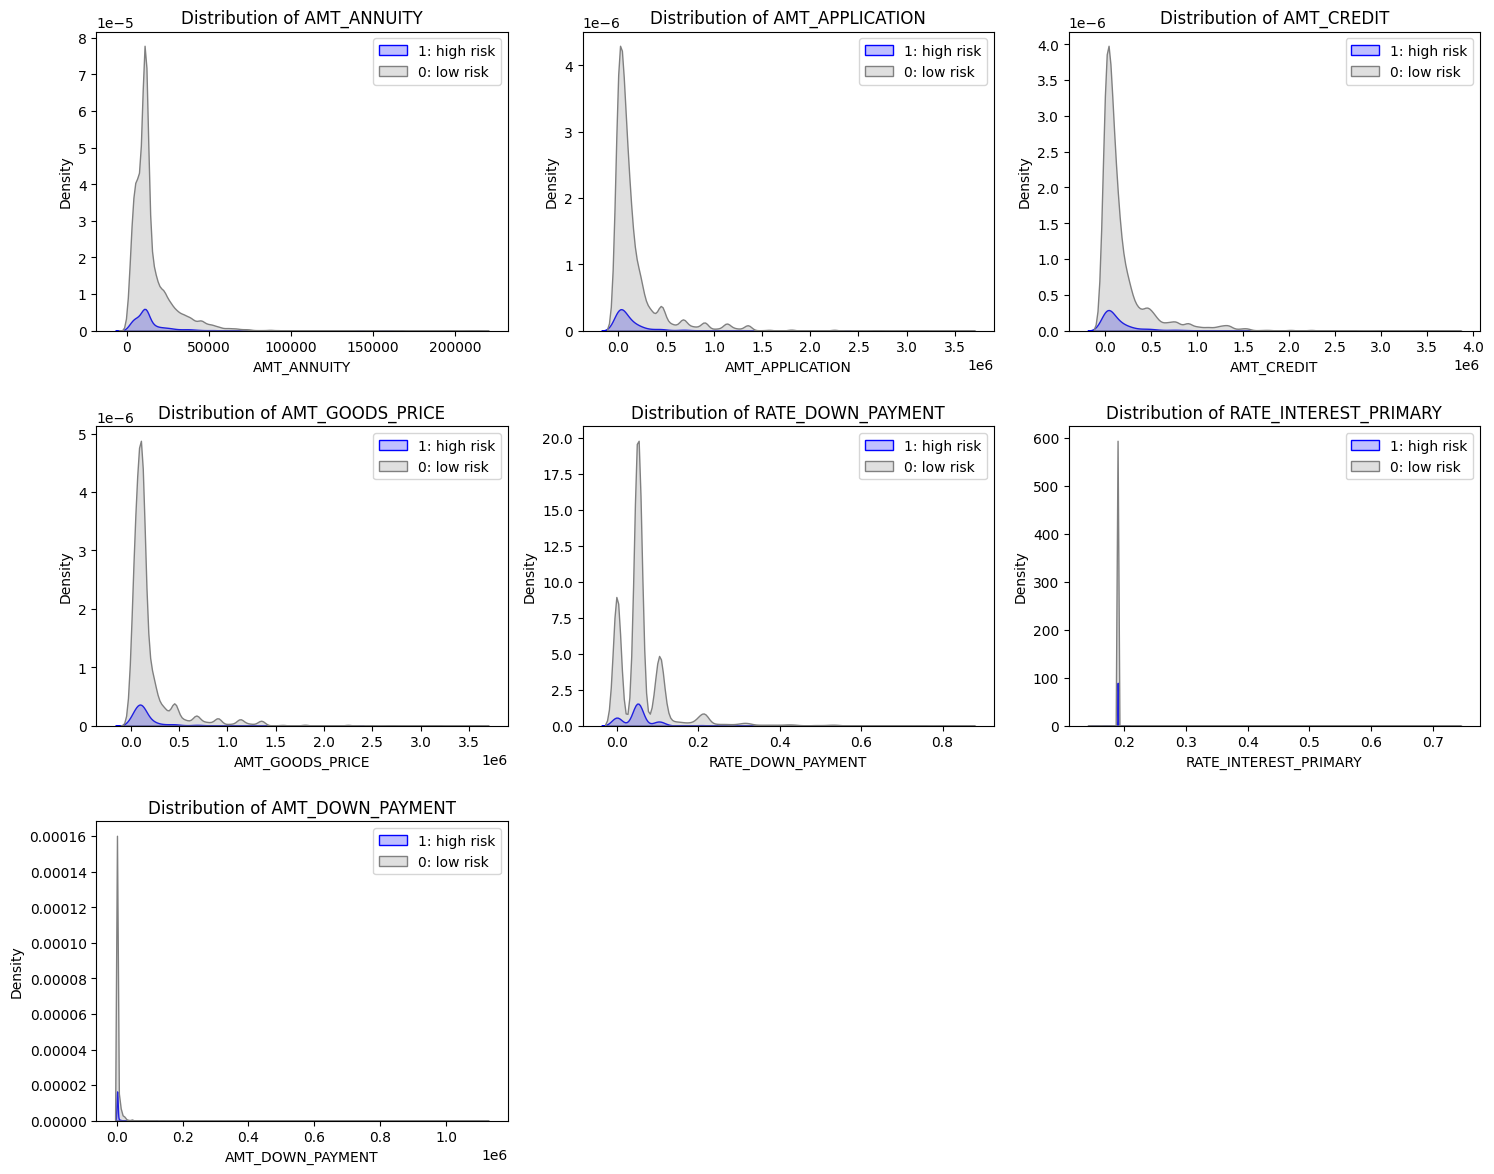

In [41]:
cols = ['AMT_ANNUITY','AMT_APPLICATION',
       'AMT_CREDIT','AMT_GOODS_PRICE','RATE_DOWN_PAYMENT',
       'RATE_INTEREST_PRIMARY','AMT_DOWN_PAYMENT']

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = previous_application.merge(application_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='left').copy()
    data[col] = data[col].fillna(data[col].median())
    ax = axes[i]
    sns.kdeplot(data, x=col, fill=True, hue='TARGET',
                palette={0:'grey', 1:'blue'}, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f'Distribution of {col}')
    ax.legend(['1: high risk', '0: low risk'])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

del cols, n_cols, n_rows, fig, axes, data, ax

In [42]:
for col in ['AMT_ANNUITY','AMT_APPLICATION',
       'AMT_CREDIT','AMT_GOODS_PRICE','RATE_DOWN_PAYMENT',
       'RATE_INTEREST_PRIMARY','AMT_DOWN_PAYMENT']:
    print(previous_application[col].describe().round(1))
    print(f"99th percentile: {previous_application[col].quantile(.99)}")
    print()

count    883723.0
mean      15871.2
std       14733.7
min           0.0
25%        6296.0
50%       11250.0
75%       20492.5
max      418058.1
Name: AMT_ANNUITY, dtype: float64
99th percentile: 69456.70530000013

count    1135707.0
mean      174021.3
std       290751.9
min            0.0
25%        19086.8
50%        70776.0
75%       180000.0
max      6905160.0
Name: AMT_APPLICATION, dtype: float64
99th percentile: 1350000.0

count    1135706.0
mean      194693.9
std       316585.4
min            0.0
25%        24309.0
50%        80100.0
75%       213948.0
max      6905160.0
Name: AMT_CREDIT, dtype: float64
99th percentile: 1506816.0

count     875265.0
mean      225828.4
std       313064.2
min            0.0
25%        50499.0
50%       111136.5
75%       229500.0
max      6905160.0
Name: AMT_GOODS_PRICE, dtype: float64
99th percentile: 1372500.0

count    531034.0
mean          0.1
std           0.1
min          -0.0
25%           0.0
50%           0.1
75%           0.1
max        

Distribution looks heavily right skewed.¶
There are 4 negative values. Will replace them with 0.
Filling all NaN with median.
Cap at 99th percentile and filling NaN with median¶

In [43]:
for col in ['AMT_ANNUITY','AMT_APPLICATION',
            'AMT_CREDIT','AMT_GOODS_PRICE','RATE_DOWN_PAYMENT',
            'RATE_INTEREST_PRIMARY','AMT_DOWN_PAYMENT']:
    previous_application[col].fillna(previous_application[col].median(), inplace=True)
    if previous_application[col].min() < 0:
        previous_application.loc[previous_application[col] < 0, col] = 0

for col in ['AMT_ANNUITY','AMT_APPLICATION',
            'AMT_CREDIT','AMT_GOODS_PRICE','AMT_DOWN_PAYMENT']:
    previous_application[col] = np.where(previous_application[col] > previous_application[col].quantile(.99),
                             previous_application[col].quantile(.99),
                             previous_application[col])

previous_application.head()

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15.0,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,1642.5,607500.0,THURSDAY,11.0,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,1642.5,112500.0,TUESDAY,11.0,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,1642.5,450000.0,MONDAY,7.0,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,1642.5,337500.0,THURSDAY,9.0,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


**Features from installments payments table¶
It is payment history for previous loans at Home Credit.
There is one row for every made payment and one row for every missed payment.**

In [44]:
installments_payments[['AMT_PAYMENT','AMT_INSTALMENT']].isna().sum()

,0
AMT_PAYMENT,761
AMT_INSTALMENT,1


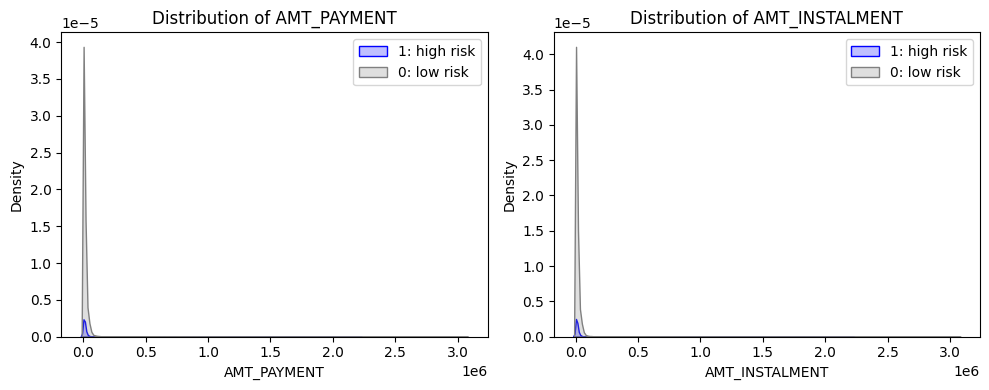

In [45]:
cols = ['AMT_PAYMENT','AMT_INSTALMENT']

n_cols = 2
n_rows = 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = installments_payments.merge(application_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='left').copy()
    data[col] = data[col].fillna(data[col].median())
    ax = axes[i]
    sns.kdeplot(data, x=col, fill=True, hue='TARGET',
                palette={0:'grey', 1:'blue'}, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f'Distribution of {col}')
    ax.legend(['1: high risk', '0: low risk'])

plt.tight_layout()
plt.show()

In [46]:
for col in ['AMT_PAYMENT','AMT_INSTALMENT']:
    print(installments_payments[col].describe().round(1))
    print(f"99th percentile: {installments_payments[col].quantile(.99)}")
    print()

count    3866146.0
mean       17236.2
std        55136.2
min            0.0
25%         3400.4
50%         8131.7
75%        16056.8
max      3473582.9
Name: AMT_PAYMENT, dtype: float64
99th percentile: 178008.20549999818

count    3866906.0
mean       17061.8
std        51039.8
min            0.0
25%         4227.1
50%         8884.1
75%        16661.8
max      3473582.9
Name: AMT_INSTALMENT, dtype: float64
99th percentile: 147338.61750000142



Distribution looks heavily right skewed¶
Cap at 99th percentile and filling NaN with median

In [47]:
for col in ['AMT_PAYMENT','AMT_INSTALMENT']:
    installments_payments[col] = np.where(installments_payments[col] > installments_payments[col].quantile(.99),
                                          installments_payments[col].quantile(.99),
                                          installments_payments[col])
    installments_payments[col].fillna(installments_payments[col].median(), inplace=True)

installments_payments.head()

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6.0,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34.0,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1.0,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3.0,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2.0,-1383.0,-1366.0,2165.040,2160.585


**Features from credit card calance table¶
It is monthly data about previous credit cards clients have had with Home Credit.
Each row is one month of a credit card balance, and a single credit card can have many rows.**

In [48]:
credit_card_balance[['AMT_BALANCE','AMT_CREDIT_LIMIT_ACTUAL',
                     'AMT_DRAWINGS_CURRENT','AMT_PAYMENT_CURRENT','AMT_INST_MIN_REGULARITY']].isna().sum()

,0
AMT_BALANCE,0
AMT_CREDIT_LIMIT_ACTUAL,0
AMT_DRAWINGS_CURRENT,0
AMT_PAYMENT_CURRENT,118379
AMT_INST_MIN_REGULARITY,40570


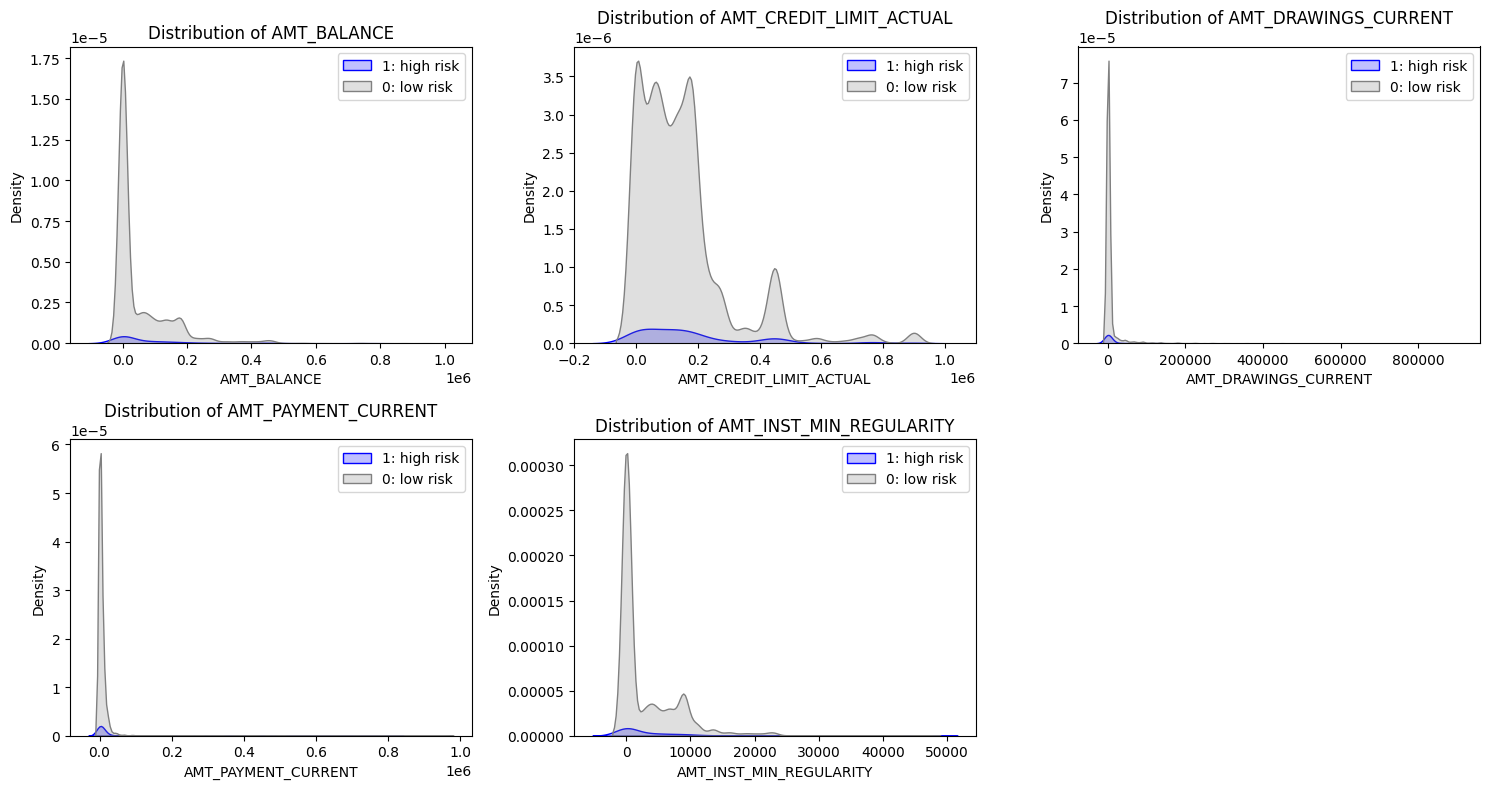

In [49]:
cols = ['AMT_BALANCE','AMT_CREDIT_LIMIT_ACTUAL',
        'AMT_DRAWINGS_CURRENT','AMT_PAYMENT_CURRENT','AMT_INST_MIN_REGULARITY']

n_cols = 3
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = credit_card_balance.merge(application_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='left').copy()
    data[col] = data[col].fillna(0)
    ax = axes[i]
    sns.kdeplot(data, x=col, fill=True, hue='TARGET',
                palette={0:'grey', 1:'blue'}, ax=ax)
    ax.set_xlabel(col)
    ax.set_title(f'Distribution of {col}')
    ax.legend(['1: high risk', '0: low risk'])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

del cols, n_cols, n_rows, fig, axes, data, ax

In [50]:
for col in ['AMT_BALANCE','AMT_CREDIT_LIMIT_ACTUAL',
        'AMT_DRAWINGS_CURRENT','AMT_PAYMENT_CURRENT','AMT_INST_MIN_REGULARITY']:
    print(credit_card_balance[col].describe().round(1))
    print(f"99th percentile: {credit_card_balance[col].quantile(.99)}")
    print()

count     563531.0
mean       55235.5
std       100547.6
min      -261471.0
25%            0.0
50%            0.0
75%        85715.2
max      1210510.8
Name: AMT_BALANCE, dtype: float64
99th percentile: 457659.7379999996

count     563531.0
mean      150518.2
std       161383.1
min            0.0
25%        45000.0
50%       112500.0
75%       180000.0
max      1350000.0
Name: AMT_CREDIT_LIMIT_ACTUAL, dtype: float64
99th percentile: 765000.0

count     563531.0
mean        6490.3
std        30761.3
min        -1687.5
25%            0.0
50%            0.0
75%            0.0
max      1440180.0
Name: AMT_DRAWINGS_CURRENT, dtype: float64
99th percentile: 141750.0

count     445152.0
mean        9793.2
std        34228.9
min            0.0
25%          144.8
50%         2614.5
75%         9000.0
max      1562251.5
Name: AMT_PAYMENT_CURRENT, dtype: float64
99th percentile: 142396.3610999997

count    522961.0
mean       3397.1
std        5359.4
min           0.0
25%           0.0
50%        

Distribution looks heavily right skewed¶
Fill na with 0
Cap at 99th percentile**

In [51]:
for col in ['AMT_BALANCE','AMT_CREDIT_LIMIT_ACTUAL',
            'AMT_DRAWINGS_CURRENT','AMT_PAYMENT_CURRENT','AMT_INST_MIN_REGULARITY']:
    credit_card_balance[col] = np.where(credit_card_balance[col] > credit_card_balance[col].quantile(.99),
                                        credit_card_balance[col].quantile(.99),
                                        credit_card_balance[col])
    credit_card_balance[col].fillna(0, inplace=True)

credit_card_balance.head()

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000.0,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0.0,0.0
1,2582071,363914,-1,63975.555,45000.0,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0.0,0.0
2,1740877,371185,-7,31815.225,450000.0,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0.0,0.0
3,1389973,337855,-4,236572.110,225000.0,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0.0,0.0
4,1891521,126868,-1,453919.455,450000.0,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0.0,0.0


**Features from bureau balance table¶
This table is similar to bureau.csv table.
It concerns client's earlier credits from other financial institutions.
A single client might have taken other loans from other financial institutions.
For each row in the application_train data we can have multiple rows in this table (one to many relationship).**

In [52]:
bureau_balance[['STATUS','MONTHS_BALANCE']].isna().sum()
# bureau_balance[['STATUS','MONTHS_BALANCE']].dtypes

,0
STATUS,1
MONTHS_BALANCE,1


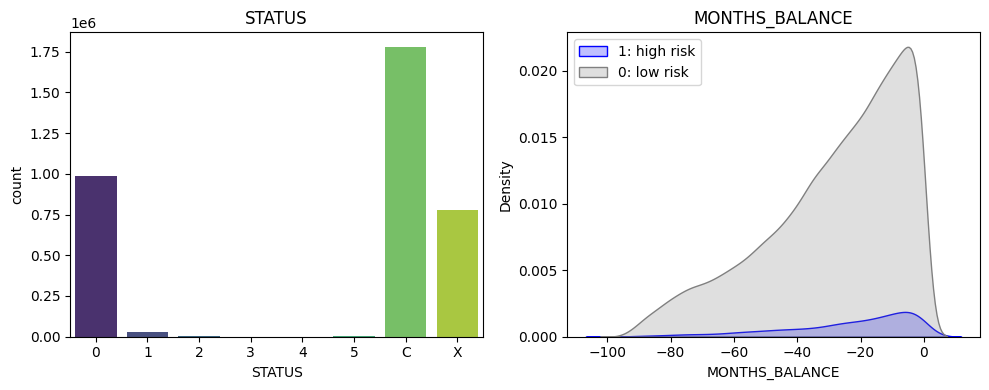

In [53]:
cols = ['STATUS', 'MONTHS_BALANCE']

n_cols = 2
n_rows = int(np.ceil(len(cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = bureau_balance.merge(bureau[['SK_ID_CURR','SK_ID_BUREAU']], on='SK_ID_BUREAU', how='left').merge(application_train[['SK_ID_CURR','TARGET']], on='SK_ID_CURR', how='left')
    ax = axes[i]
    if col == 'MONTHS_BALANCE':
        sns.kdeplot(data=data, x=col, fill=True, hue='TARGET',
                    palette={0: 'grey', 1: 'blue'}, ax=ax)
        ax.legend(['1: high risk', '0: low risk'])
    else:
        sns.countplot(data=data, x=col, ax=ax, palette="viridis")

    ax.set_xlabel(col)
    ax.set_title(col)

# Remove any extra axes if the grid is larger than needed
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Clean up variables
del cols, n_cols, n_rows, fig, axes, data, ax

In [54]:
bureau_balance['MONTHS_BALANCE'].describe().round(1)

,MONTHS_BALANCE
count,3584519.0
mean,-29.9
std,23.5
min,-96.0
25%,-44.0
50%,-24.0
75%,-11.0
max,0.0


**Probably won't include MONTHS_BALANCE¶
Creating the Final Table for Modelling
Merging the Columns from the other tables to the Main Table
Engineering Features for the final table
Only focusing on features that represent financial capabilities**

Creating the Final Table for Modelling¶
Merging the Columns from the other tables to the Main Table
Engineering Features for the final table
Only focusing on features that represent financial capabilities

In [55]:
# Step 1: Aggregate bureau data (original + additional monetary features)
# 'AMT_CREDIT_MAX_OVERDUE','overdue_flag','AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM'
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_MAX_OVERDUE': 'sum',
    'overdue_flag': 'sum',
    'AMT_CREDIT_SUM_DEBT': 'sum',
    'AMT_CREDIT_SUM': 'sum'
})
bureau_agg.columns = ['bureau_' + col + '_sum' for col in bureau_agg.columns]

# Step 2: Aggregate previous application data (original + additional monetary features)
# 'AMT_ANNUITY','AMT_APPLICATION','AMT_CREDIT','AMT_GOODS_PRICE','RATE_DOWN_PAYMENT','RATE_INTEREST_PRIMARY','AMT_DOWN_PAYMENT'
prev_app_agg = previous_application.groupby('SK_ID_CURR').agg({
    'SK_ID_PREV': 'count',
    'AMT_ANNUITY': 'sum',
    'AMT_APPLICATION': 'sum',
    'AMT_CREDIT': 'sum',
    'AMT_GOODS_PRICE': 'sum',
    'RATE_DOWN_PAYMENT': 'max',
    'RATE_INTEREST_PRIMARY': 'max',
    'AMT_DOWN_PAYMENT': 'sum'
})
prev_app_agg.columns = ['prev_app_' + col for col in prev_app_agg.columns]

# Step 3: Aggregate installments payments data (new monetary features)
# 'AMT_PAYMENT','AMT_INSTALMENT'
installments_payments_agg = installments_payments.groupby('SK_ID_CURR').agg({
    'AMT_PAYMENT': ['sum', 'mean'],
    'AMT_INSTALMENT': ['sum', 'mean']
})
installments_payments_agg.columns = ['installments_' + '_'.join(col).strip() for col in installments_payments_agg.columns]

# Step 4: Aggregate credit card balance data (new monetary features)
# 'AMT_BALANCE','AMT_CREDIT_LIMIT_ACTUAL','AMT_DRAWINGS_CURRENT','AMT_PAYMENT_CURRENT','AMT_INST_MIN_REGULARITY'
credit_card_balance['payment_diff'] = credit_card_balance['AMT_PAYMENT_CURRENT'] - credit_card_balance['AMT_INST_MIN_REGULARITY']
cc_agg = credit_card_balance.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': ['mean', 'sum'],
    'AMT_CREDIT_LIMIT_ACTUAL': ['mean', 'sum'],
    'AMT_DRAWINGS_CURRENT': 'sum',
    'payment_diff': 'sum'
})
cc_agg.columns = ['cc_' + '_'.join(col).strip() for col in cc_agg.columns]

# Step 5: Engineer numerical features from bureau_balance
bureau_balance_with_curr = bureau_balance.merge(bureau[['SK_ID_BUREAU', 'SK_ID_CURR']], on='SK_ID_BUREAU', how='left')
bureau_balance_with_curr['overdue'] = bureau_balance_with_curr['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)
bureau_balance_agg = bureau_balance_with_curr.groupby('SK_ID_CURR').agg({
    'overdue': 'sum'
})
bureau_balance_agg.columns = ['bureau_balance_' + col for col in bureau_balance_agg.columns]

# Step 6: Merge all aggregations with app_train
model_df = application_train.merge(bureau_agg, how='left', left_on='SK_ID_CURR', right_index=True) \
                    .merge(prev_app_agg, how='left', left_on='SK_ID_CURR', right_index=True) \
                    .merge(installments_payments_agg, how='left', left_on='SK_ID_CURR', right_index=True) \
                    .merge(cc_agg, how='left', left_on='SK_ID_CURR', right_index=True) \
                    .merge(bureau_balance_agg, how='left', left_on='SK_ID_CURR', right_index=True)

# Step 7: Add derived features using columns from the merged DataFrame
model_df = model_df.assign(
    credit_to_income=lambda x: x['AMT_CREDIT'] / x['AMT_INCOME_TOTAL'],
    annuity_to_income=lambda x: x['AMT_ANNUITY'] / x['AMT_INCOME_TOTAL'],
    social_circ_default=lambda x: x['DEF_30_CNT_SOCIAL_CIRCLE'] + x['DEF_60_CNT_SOCIAL_CIRCLE']
)

# Step 8: One-hot encode the categorical features
categorical_features = ['NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE']
model_df = pd.get_dummies(model_df, columns=categorical_features, dummy_na=True)

# Step 9: Select desired columns (original features + new monetary features)
selected_columns = [
    'TARGET',
    'bureau_AMT_CREDIT_MAX_OVERDUE_sum',
    'bureau_AMT_CREDIT_SUM_DEBT_sum',
    'bureau_overdue_flag_sum',
    'bureau_AMT_CREDIT_SUM_sum',

    'prev_app_SK_ID_PREV',
    'prev_app_AMT_DOWN_PAYMENT',
    'prev_app_AMT_ANNUITY',
    'prev_app_AMT_APPLICATION',
    'prev_app_AMT_CREDIT',
    'prev_app_AMT_GOODS_PRICE',
    'prev_app_RATE_DOWN_PAYMENT',
    'prev_app_RATE_INTEREST_PRIMARY',

    'credit_to_income',
    'annuity_to_income',
    'social_circ_default',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'AMT_GOODS_PRICE',

    'installments_AMT_PAYMENT_sum',
    'installments_AMT_PAYMENT_mean',
    'installments_AMT_INSTALMENT_sum',
    'installments_AMT_INSTALMENT_mean',

    'cc_AMT_BALANCE_mean',
    'cc_AMT_BALANCE_sum',
    'cc_AMT_CREDIT_LIMIT_ACTUAL_mean',
    'cc_AMT_CREDIT_LIMIT_ACTUAL_sum',
    'cc_AMT_DRAWINGS_CURRENT_sum',
    'cc_payment_diff_sum',

    'bureau_balance_overdue',

    # Encoded categorical features
    *model_df.filter(like='NAME_CONTRACT_TYPE_').columns,
    *model_df.filter(like='NAME_INCOME_TYPE_').columns,
    *model_df.filter(like='NAME_EDUCATION_TYPE_').columns
]

# Final DataFrame with selected columns
model_df = model_df[selected_columns]
model_df.head()

,TARGET,bureau_AMT_CREDIT_MAX_OVERDUE_sum,bureau_AMT_CREDIT_SUM_DEBT_sum,bureau_overdue_flag_sum,bureau_AMT_CREDIT_SUM_sum,prev_app_SK_ID_PREV,prev_app_AMT_DOWN_PAYMENT,prev_app_AMT_ANNUITY,prev_app_AMT_APPLICATION,prev_app_AMT_CREDIT,...,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_INCOME_TYPE_nan,NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / seco,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_EDUCATION_TYPE_nan
0,1,8405.145,0.0,0.0,347555.565,1.0,0.0,9251.7750,179055.0,179055.0,...,False,True,False,False,False,False,False,False,True,False
1,0,0.000,0.0,0.0,1017400.500,2.0,1642.5,130110.1542,1237500.0,1384519.5,...,False,False,False,False,True,False,False,False,False,False
2,0,0.000,0.0,0.0,189037.800,1.0,4860.0,5357.2500,24282.0,20106.0,...,False,True,False,False,False,False,False,False,True,False
3,0,NaN,NaN,NaN,NaN,5.0,51570.0,117978.0300,1734417.0,1694425.5,...,False,True,False,False,False,False,False,False,True,False
4,0,NaN,NaN,NaN,NaN,4.0,8604.0,47392.5150,669676.5,753304.5,...,False,True,False,False,False,False,False,False,True,False


In [56]:
for var_name in ['bureau_agg', 'prev_app_agg', 'installments_payments_agg', 'cc_agg', 'selected_columns', 'categorical_features',
                 'bureau_balance_agg', 'bureau_balance_with_curr',
                 'application_train', 'bureau', 'previous_application', 'installments_payments', 'credit_card_balance', 'bureau_balance']:
    globals().pop(var_name, None)
model_df.isna().sum()

,0
TARGET,0
bureau_AMT_CREDIT_MAX_OVERDUE_sum,4503
bureau_AMT_CREDIT_SUM_DEBT_sum,4503
bureau_overdue_flag_sum,4503
bureau_AMT_CREDIT_SUM_sum,4503
prev_app_SK_ID_PREV,1452
prev_app_AMT_DOWN_PAYMENT,1452
prev_app_AMT_ANNUITY,1452
prev_app_AMT_APPLICATION,1452
prev_app_AMT_CREDIT,1452


In [57]:
zero_cols = [
    'bureau_AMT_CREDIT_MAX_OVERDUE_sum',
    'bureau_AMT_CREDIT_SUM_DEBT_sum',
    'bureau_overdue_flag_sum',
    'bureau_AMT_CREDIT_SUM_sum',
    'prev_app_SK_ID_PREV',
    'prev_app_AMT_DOWN_PAYMENT',
    'prev_app_AMT_ANNUITY',
    'prev_app_AMT_APPLICATION',
    'prev_app_AMT_CREDIT',
    'prev_app_AMT_GOODS_PRICE',
    'prev_app_RATE_DOWN_PAYMENT',
    'prev_app_RATE_INTEREST_PRIMARY',
    'installments_AMT_PAYMENT_sum',
    'installments_AMT_PAYMENT_mean',
    'installments_AMT_INSTALMENT_sum',
    'installments_AMT_INSTALMENT_mean',
    'cc_AMT_BALANCE_mean',
    'cc_AMT_BALANCE_sum',
    'cc_AMT_CREDIT_LIMIT_ACTUAL_mean',
    'cc_AMT_CREDIT_LIMIT_ACTUAL_sum',
    'cc_AMT_DRAWINGS_CURRENT_sum',
    'cc_payment_diff_sum',
    'bureau_balance_overdue',
    'annuity_to_income',
    'social_circ_default'
]

median_cols = [
    'AMT_GOODS_PRICE'
]

for col in zero_cols:
    model_df[col].fillna(0, inplace=True)

for col in median_cols:
    model_df[col].fillna(model_df[col].median(), inplace=True)

model_df.isna().sum()

,0
TARGET,0
bureau_AMT_CREDIT_MAX_OVERDUE_sum,0
bureau_AMT_CREDIT_SUM_DEBT_sum,0
bureau_overdue_flag_sum,0
bureau_AMT_CREDIT_SUM_sum,0
prev_app_SK_ID_PREV,0
prev_app_AMT_DOWN_PAYMENT,0
prev_app_AMT_ANNUITY,0
prev_app_AMT_APPLICATION,0
prev_app_AMT_CREDIT,0


In [58]:
del zero_cols, median_cols

memory_optimizer(model_df)
model_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11631 entries, 0 to 11630
Data columns (total 48 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   TARGET                                             11631 non-null  int8   
 1   bureau_AMT_CREDIT_MAX_OVERDUE_sum                  11631 non-null  float64
 2   bureau_AMT_CREDIT_SUM_DEBT_sum                     11631 non-null  float64
 3   bureau_overdue_flag_sum                            11631 non-null  float32
 4   bureau_AMT_CREDIT_SUM_sum                          11631 non-null  float64
 5   prev_app_SK_ID_PREV                                11631 non-null  float32
 6   prev_app_AMT_DOWN_PAYMENT                          11631 non-null  float64
 7   prev_app_AMT_ANNUITY                               11631 non-null  float64
 8   prev_app_AMT_APPLICATION                           11631 non-null  float64
 9   prev_a

In [59]:
# Removed: from xgboost.callback import EarlyStopping # Import EarlyStopping

def tune_xgb(df):
    X = df.drop(columns='TARGET')
    y = df['TARGET']
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    def objective(trial):
        # Define hyperparameter search space
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
            'max_delta_step': trial.suggest_int('max_delta_step', 0, 10),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 20.0)
        }

        # Create and train the model without early stopping
        model = XGBClassifier(**params, objective='binary:logistic', eval_metric='auc', random_state=42, n_jobs=-1)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False # Set verbose to False during Optuna trials to avoid excessive output
        )

        # Predict probabilities on validation set and calculate Metrics
        # Since early_stopping_rounds is not supported, use n_estimators for iteration range
        best_iteration = model.n_estimators
        y_pred_proba = model.predict_proba(X_val, iteration_range=(0, best_iteration))[:, 1]
        auc = roc_auc_score(y_val, y_pred_proba)
        return auc

    # start studying
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)

    # final model
    xgb = XGBClassifier(**study.best_params, objective='binary:logistic', eval_metric='auc', random_state=42, n_jobs=-1)
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=True # Can be True for final model for visibility
    )

    # Use the best model from the final fit
    best_iteration = xgb.n_estimators
    y_pred_proba = xgb.predict_proba(X_val, iteration_range=(0, best_iteration))[:, 1]

    return y_val, xgb, y_pred_proba
y_val, xgb, y_pred_proba = tune_xgb(model_df)

[I 2026-04-20 06:10:03,014] A new study created in memory with name: no-name-38fd4598-b9bc-40ae-a7d6-34c2f56da647
[I 2026-04-20 06:10:04,860] Trial 0 finished with value: 0.7106244967850945 and parameters: {'n_estimators': 522, 'subsample': 0.6419181800626053, 'colsample_bytree': 0.7092713624614724, 'colsample_bylevel': 0.9878639338904536, 'colsample_bynode': 0.7462572638786122, 'max_depth': 3, 'learning_rate': 0.2106584661439388, 'gamma': 1.4678688008562202, 'min_child_weight': 5, 'reg_alpha': 0.9145048438658776, 'reg_lambda': 0.8000684811773795, 'max_delta_step': 10, 'scale_pos_weight': 8.677258895485}. Best is trial 0 with value: 0.7106244967850945.
[I 2026-04-20 06:10:08,162] Trial 1 finished with value: 0.731589421997437 and parameters: {'n_estimators': 361, 'subsample': 0.9615586884477487, 'colsample_bytree': 0.6154102560777084, 'colsample_bylevel': 0.8994556577361446, 'colsample_bynode': 0.8412067390374867, 'max_depth': 10, 'learning_rate': 0.19349161485404484, 'gamma': 3.282341

[0]	validation_0-auc:0.69758
[1]	validation_0-auc:0.71664
[2]	validation_0-auc:0.73817
[3]	validation_0-auc:0.73730
[4]	validation_0-auc:0.73865
[5]	validation_0-auc:0.74416
[6]	validation_0-auc:0.74182
[7]	validation_0-auc:0.74160
[8]	validation_0-auc:0.74344
[9]	validation_0-auc:0.74364
[10]	validation_0-auc:0.74419
[11]	validation_0-auc:0.74099
[12]	validation_0-auc:0.73984
[13]	validation_0-auc:0.74492
[14]	validation_0-auc:0.74406
[15]	validation_0-auc:0.74766
[16]	validation_0-auc:0.74919
[17]	validation_0-auc:0.74953
[18]	validation_0-auc:0.75163
[19]	validation_0-auc:0.75062
[20]	validation_0-auc:0.75139
[21]	validation_0-auc:0.75229
[22]	validation_0-auc:0.75203
[23]	validation_0-auc:0.75222
[24]	validation_0-auc:0.75295
[25]	validation_0-auc:0.75324
[26]	validation_0-auc:0.75297
[27]	validation_0-auc:0.75276
[28]	validation_0-auc:0.75263
[29]	validation_0-auc:0.75304
[30]	validation_0-auc:0.75332
[31]	validation_0-auc:0.75402
[32]	validation_0-auc:0.75331
[33]	validation_0-au

[I 2026-04-20 06:13:12,763] A new study created in memory with name: no-name-25198741-1197-4382-bd4c-4c05caac5bf7
[I 2026-04-20 06:13:14,247] Trial 0 finished with value: 0.7202748829139405 and parameters: {'n_estimators': 449, 'subsample': 0.9377050015163977, 'colsample_bytree': 0.609334055450323, 'colsample_bylevel': 0.7098510471658072, 'colsample_bynode': 0.6330246205480441, 'max_depth': 8, 'learning_rate': 0.2856258366840631, 'gamma': 2.2862074402197297, 'min_child_weight': 8, 'reg_alpha': 0.08099760119602273, 'reg_lambda': 0.8536110092830056, 'max_delta_step': 3, 'scale_pos_weight': 19.6061680380762}. Best is trial 0 with value: 0.7202748829139405.
[I 2026-04-20 06:13:19,317] Trial 1 finished with value: 0.7334718709955433 and parameters: {'n_estimators': 674, 'subsample': 0.6845119045628307, 'colsample_bytree': 0.6500302983816669, 'colsample_bylevel': 0.9108252932557096, 'colsample_bynode': 0.7837899374395347, 'max_depth': 10, 'learning_rate': 0.04769433284925014, 'gamma': 1.6008

[0]	validation_0-auc:0.68883
[1]	validation_0-auc:0.72806
[2]	validation_0-auc:0.72639
[3]	validation_0-auc:0.73341
[4]	validation_0-auc:0.73684
[5]	validation_0-auc:0.72409
[6]	validation_0-auc:0.73348
[7]	validation_0-auc:0.73525
[8]	validation_0-auc:0.74150
[9]	validation_0-auc:0.73374
[10]	validation_0-auc:0.73752
[11]	validation_0-auc:0.74392
[12]	validation_0-auc:0.74361
[13]	validation_0-auc:0.74840
[14]	validation_0-auc:0.74565
[15]	validation_0-auc:0.74782
[16]	validation_0-auc:0.74917
[17]	validation_0-auc:0.75048
[18]	validation_0-auc:0.75156
[19]	validation_0-auc:0.75157
[20]	validation_0-auc:0.75349
[21]	validation_0-auc:0.75330
[22]	validation_0-auc:0.75295
[23]	validation_0-auc:0.75474
[24]	validation_0-auc:0.75732
[25]	validation_0-auc:0.75821
[26]	validation_0-auc:0.75792
[27]	validation_0-auc:0.75815
[28]	validation_0-auc:0.75716
[29]	validation_0-auc:0.75594
[30]	validation_0-auc:0.75624
[31]	validation_0-auc:0.75706
[32]	validation_0-auc:0.75842
[33]	validation_0-au

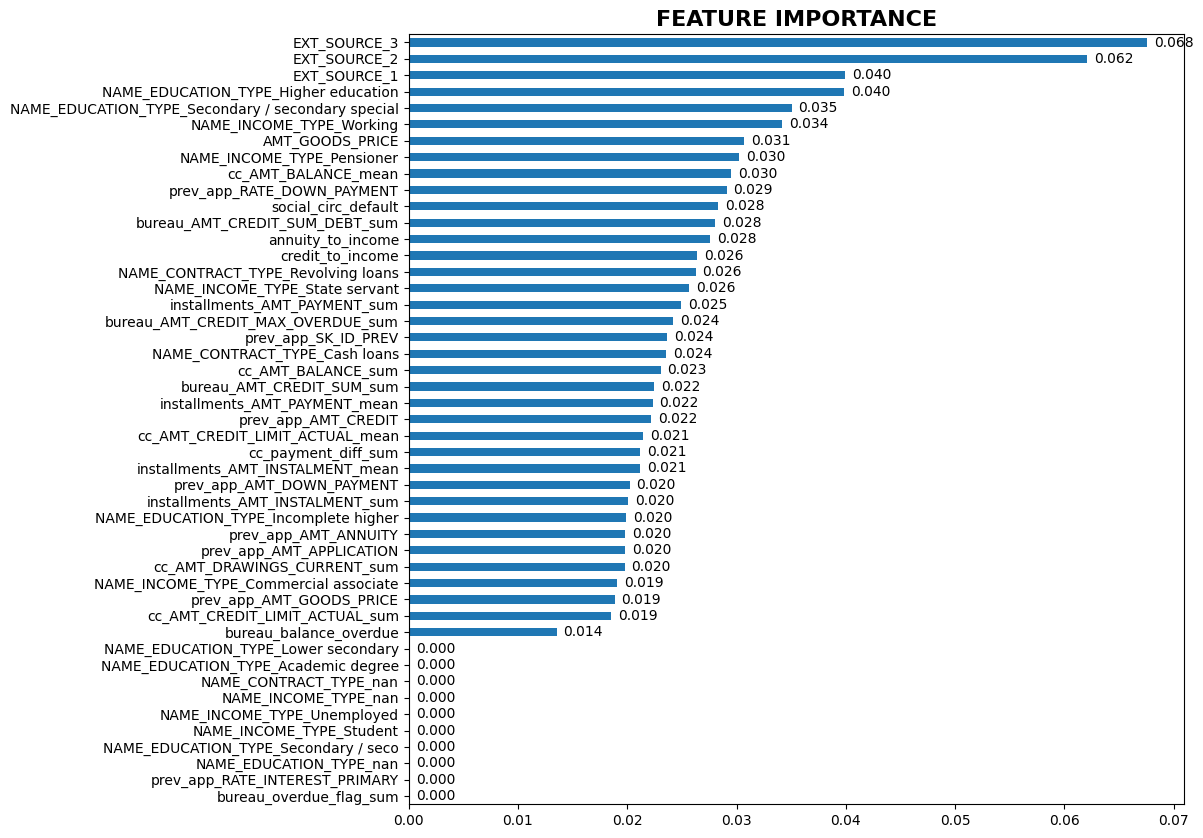

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Re-run tune_xgb to ensure 'xgb' is defined. This will re-run hyperparameter tuning.
y_val, xgb, y_pred_proba = tune_xgb(model_df)

ax = pd.Series(
    xgb.feature_importances_,
    index=model_df.drop(columns='TARGET').columns
).sort_values().plot(kind='barh', figsize=(10, 10))

plt.title('FEATURE IMPORTANCE', fontweight='bold', fontsize=16)

for patch in ax.patches:
    width = patch.get_width()
    ax.annotate(f'{width:.3f}',
                xy=(width, patch.get_y() + patch.get_height() / 2),
                xytext=(5, 0),
                textcoords='offset points',
                va='center', fontsize=10)

plt.show()

In [61]:
print('Checking XGBoost version:')
!pip show xgboost

Checking XGBoost version:
Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: 


In [62]:
# Separate features and target
X = model_df.drop(columns=["TARGET"])
y = model_df["TARGET"]

print(X.shape, y.shape)

(11631, 47) (11631,)


In [63]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,   # important for imbalance
    random_state=42
)

print(X_train.shape, X_test.shape)

(9304, 47) (2327, 47)


In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",  # handles imbalance
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [66]:
# Probability predictions
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Convert to class (threshold = 0.5)
y_pred = (y_probs >= 0.5).astype(int)

In [67]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# ROC AUC
roc_score = roc_auc_score(y_test, y_probs)
print("ROC AUC Score:", roc_score)

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC AUC Score: 0.745492418361538

Confusion Matrix:
[[1494  653]
 [  60  120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81      2147
           1       0.16      0.67      0.25       180

    accuracy                           0.69      2327
   macro avg       0.56      0.68      0.53      2327
weighted avg       0.90      0.69      0.76      2327



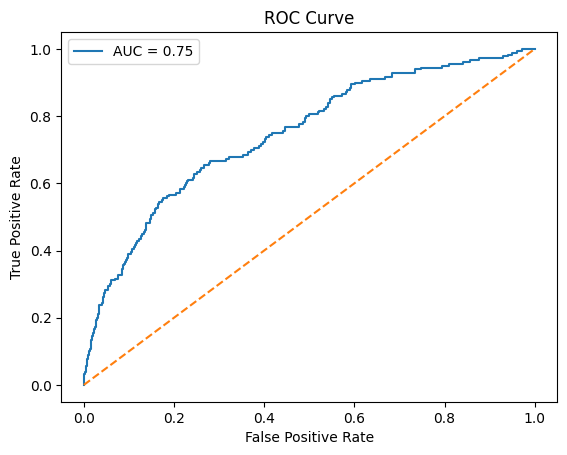

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_score:.2f}")
plt.plot([0,1], [0,1], linestyle="--")  # random model line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [69]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

print(feature_importance.head(10))

                                              Feature  Coefficient
9                            prev_app_AMT_GOODS_PRICE     0.731717
8                                 prev_app_AMT_CREDIT     0.715789
21                    installments_AMT_INSTALMENT_sum     0.697501
23                                cc_AMT_BALANCE_mean     0.363259
13                                  annuity_to_income     0.166131
14                                social_circ_default     0.146711
26                     cc_AMT_CREDIT_LIMIT_ACTUAL_sum     0.145816
1                      bureau_AMT_CREDIT_SUM_DEBT_sum     0.104044
22                   installments_AMT_INSTALMENT_mean     0.092927
45  NAME_EDUCATION_TYPE_Secondary / secondary special     0.086919


In [78]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
!pip install streamlit
import streamlit as st
import pandas as pd
import joblib

# Load files
model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")
features = joblib.load("features.pkl")

st.title("Credit Risk Predictor")

# Example inputs (you can expand this)
income = st.number_input("Income", value=100000.0)
credit = st.number_input("Credit Amount", value=500000.0)
annuity = st.number_input("Annuity", value=20000.0)

# Create input dictionary (IMPORTANT: match feature names)
input_data = {feature: 0 for feature in features}

# Fill selected features
if "AMT_INCOME_TOTAL" in input_data:
    input_data["AMT_INCOME_TOTAL"] = income
if "AMT_CREDIT" in input_data:
    input_data["AMT_CREDIT"] = credit
if "AMT_ANNUITY" in input_data:
    input_data["AMT_ANNUITY"] = annuity

# Convert to dataframe
input_df = pd.DataFrame([input_data])

# Scale
input_scaled = scaler.transform(input_df)

# Predict
if st.button("Predict"):
    prob = model.predict_proba(input_scaled)[0][1]
    prediction = "High Risk" if prob >= 0.5 else "Low Risk"

    st.write(f"Prediction: {prediction}")
    st.write(f"Risk Probability: {prob:.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 22.2 MB/s eta 0:00:00


2026-04-20 06:22:10.162 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 06:22:10.531 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-20 06:22:10.534 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 06:22:10.536 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 06:22:10.539 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 06:22:10.540 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 06:22:10.541 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 06:22:10.543 Thread 'MainThread': mi

In [75]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load files
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')
features = joblib.load('features.pkl')

st.title('Credit Risk Predictor')

# Example inputs (you can expand this)
income = st.number_input('Income', value=100000.0)
credit = st.number_input('Credit Amount', value=500000.0)
annuity = st.number_input('Annuity', value=20000.0)

# Create input dictionary (IMPORTANT: match feature names)
input_data = {feature: 0 for feature in features}

# Fill selected features
if 'AMT_INCOME_TOTAL' in input_data:
    input_data['AMT_INCOME_TOTAL'] = income
if 'AMT_CREDIT' in input_data:
    input_data['AMT_CREDIT'] = credit
if 'AMT_ANNUITY' in input_data:
    input_data['AMT_ANNUITY'] = annuity

# Convert to dataframe
input_df = pd.DataFrame([input_data])

# Scale
input_scaled = scaler.transform(input_df)

# Predict
if st.button('Predict'):
    prob = model.predict_proba(input_scaled)[:, 1]
    prediction = 'High Risk' if prob >= 0.5 else 'Low Risk'

    st.write(f'Prediction: {prediction}')
    st.write(f'Risk Probability: {prob:.2f}')

Writing app.py


In [76]:
!streamlit run app.py --browser.gatherUsageStats=False


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.65.235:8501

  Stopping...
  Stopping...


In [81]:
import os

# Install pyngrok if not already installed
!pip install pyngrok

In [86]:
from pyngrok import ngrok

# Terminate any existing ngrok tunnels
ngrok.kill()

# IMPORTANT: Replace "YOUR_ACTUAL_AUTHTOKEN_HERE" with your actual ngrok authtoken.
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("YOUR_ACTUAL_AUTHTOKEN_HERE") # <--- REPLACE THIS WITH YOUR ACTUAL TOKEN

# Start ngrok tunnel for Streamlit (default port 8501)
NGROK_TUNNEL = ngrok.connect(8501)
print(f'Streamlit Public URL: {NGROK_TUNNEL.public_url}')

ERROR:pyngrok.process.ngrok:t=2026-04-20T06:35:48+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_ACTUAL_AUTHTOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"


PyngrokNgrokError: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_ACTUAL_AUTHTOKEN_HERE\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.

Once `ngrok` is successfully set up and running, you will see a public URL. Click on that URL to access your Streamlit application.